# Patient Readmission Risk Prediction
## Random Forest Classification

This notebook trains and evaluates a Random Forest classifier to
predict whether a patient will be readmitted within 30 days.

Target:
- 1 = Readmitted within 30 days
- 0 = Not readmitted within 30 days

The dataset has already been cleaned and encoded in the preprocessing
pipeline. The same processed dataset is used for model comparison.

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    precision_recall_curve
)

In [49]:
data_path = Path("../data/processed/readmission_cleaned.csv")

df = pd.read_csv(data_path)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (101766, 112)


,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,...,insulin_Up,glyburide-metformin_No,glyburide-metformin_Steady,glyburide-metformin_Up,glipizide-metformin_Steady,glimepiride-pioglitazone_Steady,metformin-rosiglitazone_Steady,metformin-pioglitazone_Steady,change_No,diabetesMed_Yes
0,6,25,1,1,41,0,1,0,0,0,...,0,1,0,0,0,0,0,0,1,0
1,1,1,7,3,59,0,18,0,0,0,...,1,1,0,0,0,0,0,0,0,1
2,1,1,7,2,11,5,13,2,0,1,...,0,1,0,0,0,0,0,0,1,1
3,1,1,7,2,44,1,16,0,0,0,...,1,1,0,0,0,0,0,0,0,1
4,1,1,7,1,51,0,8,0,0,0,...,0,1,0,0,0,0,0,0,0,1


In [50]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nMissing values:")
print(df.isnull().sum().sum())

print("\nTarget distribution:")
print(df["readmitted_30_days"].value_counts())

print("\nTarget percentage:")
print(df["readmitted_30_days"].value_counts(normalize=True) * 100)

Number of rows: 101766
Number of columns: 112

Missing values:
0

Target distribution:
readmitted_30_days
0    90409
1    11357
Name: count, dtype: int64

Target percentage:
readmitted_30_days
0    88.840084
1    11.159916
Name: proportion, dtype: float64


In [51]:
X = df.drop(columns=["readmitted_30_days"])
y = df["readmitted_30_days"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (101766, 111)
Target shape: (101766,)


In [52]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (81412, 111)
X_test : (20354, 111)
y_train: (81412,)
y_test : (20354,)


In [53]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features="sqrt",
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

print(rf_model)

RandomForestClassifier(class_weight='balanced', n_estimators=300, n_jobs=-1,
                       random_state=42)


In [54]:
rf_model.fit(X_train, y_train)

print("Random Forest training completed.")

Random Forest training completed.


In [55]:
y_pred = rf_model.predict(X_test)

y_prob = rf_model.predict_proba(X_test)[:, 1]

print("Predictions completed.")
print("Number of predictions:", len(y_pred))

Predictions completed.
Number of predictions: 20354


In [56]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("Random Forest Performance")
print("-------------------------")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

Random Forest Performance
-------------------------
Accuracy : 0.8862
Precision: 0.4154
Recall   : 0.0498
F1 Score : 0.0889
ROC-AUC  : 0.6600


In [57]:
print("Classification Report")
print("---------------------")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Not Readmitted", "Readmitted <30 Days"]
    )
)

Classification Report
---------------------
                     precision    recall  f1-score   support

     Not Readmitted       0.89      0.99      0.94     18083
Readmitted <30 Days       0.42      0.05      0.09      2271

           accuracy                           0.89     20354
          macro avg       0.65      0.52      0.51     20354
       weighted avg       0.84      0.89      0.84     20354



In [58]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[17924   159]
 [ 2158   113]]


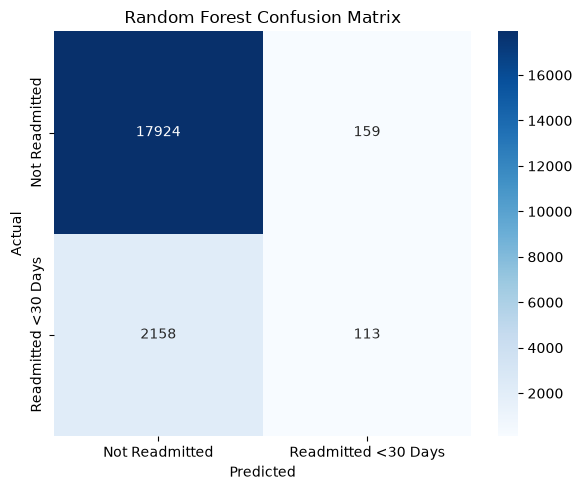

In [59]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Not Readmitted", "Readmitted <30 Days"],
    yticklabels=["Not Readmitted", "Readmitted <30 Days"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")

plt.tight_layout()
plt.show()

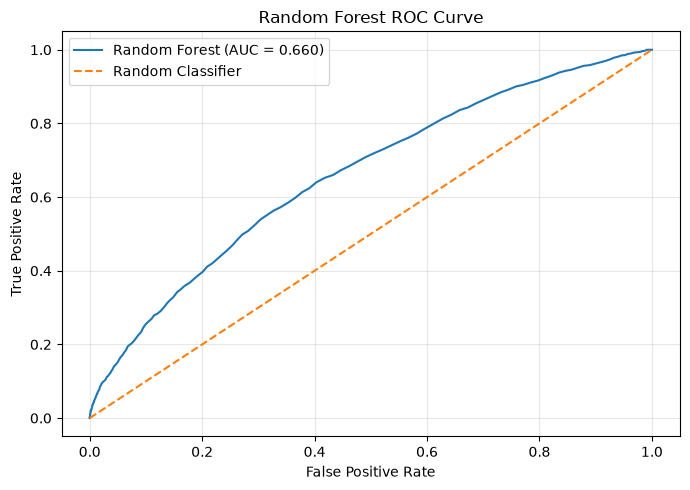

In [60]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"Random Forest (AUC = {roc_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Random Forest ROC Curve")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [61]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(20)

,Feature,Importance
4,num_lab_procedures,0.091273
6,num_medications,0.080615
3,time_in_hospital,0.058894
1,discharge_disposition_id,0.043533
5,num_procedures,0.041814
10,number_diagnoses,0.040620
11,total_previous_visits,0.037063
9,number_inpatient,0.036328
0,admission_type_id,0.029232
2,admission_source_id,0.024671


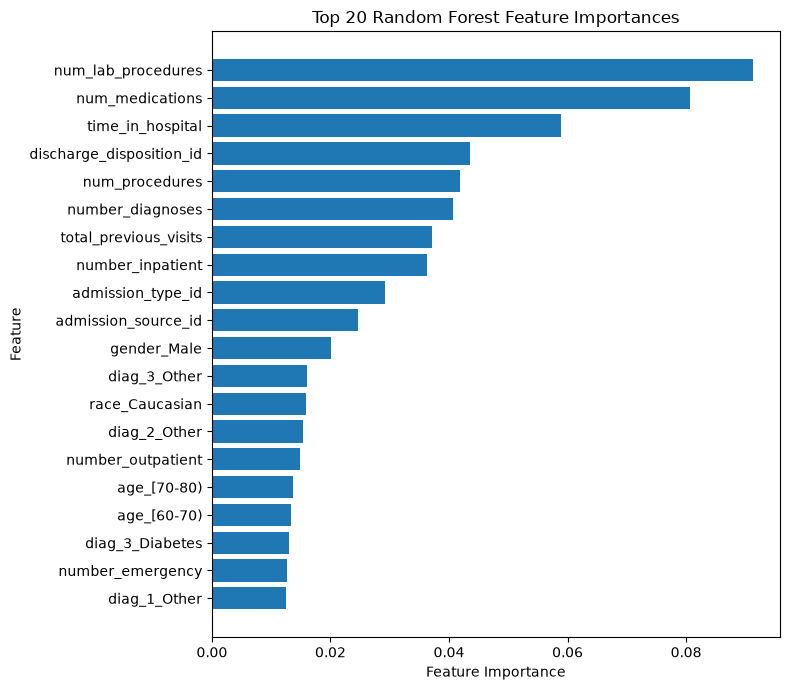

In [62]:
top_features = feature_importance.head(20).sort_values(
    by="Importance",
    ascending=True
)

plt.figure(figsize=(8, 7))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 20 Random Forest Feature Importances")

plt.tight_layout()
plt.show()

In [63]:
thresholds_to_test = [
    0.10,
    0.15,
    0.20,
    0.25,
    0.30,
    0.35,
    0.40,
    0.45,
    0.50
]

threshold_results = []

for threshold in thresholds_to_test:

    y_pred_threshold = (y_prob >= threshold).astype(int)

    precision_t = precision_score(
        y_test,
        y_pred_threshold,
        zero_division=0
    )

    recall_t = recall_score(
        y_test,
        y_pred_threshold,
        zero_division=0
    )

    f1_t = f1_score(
        y_test,
        y_pred_threshold,
        zero_division=0
    )

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_t,
        "Recall": recall_t,
        "F1 Score": f1_t
    })

threshold_df = pd.DataFrame(threshold_results)

threshold_df

,Threshold,Precision,Recall,F1 Score
0,0.10,0.117853,0.965654,0.210068
1,0.15,0.131876,0.884632,0.229534
2,0.20,0.151271,0.720387,0.250038
3,0.25,0.182265,0.539410,0.272464
4,0.30,0.210867,0.358873,0.265645
5,0.35,0.246628,0.225451,0.235565
6,0.40,0.290534,0.136504,0.185740
7,0.45,0.357766,0.090269,0.144163
8,0.50,0.415493,0.051959,0.092368


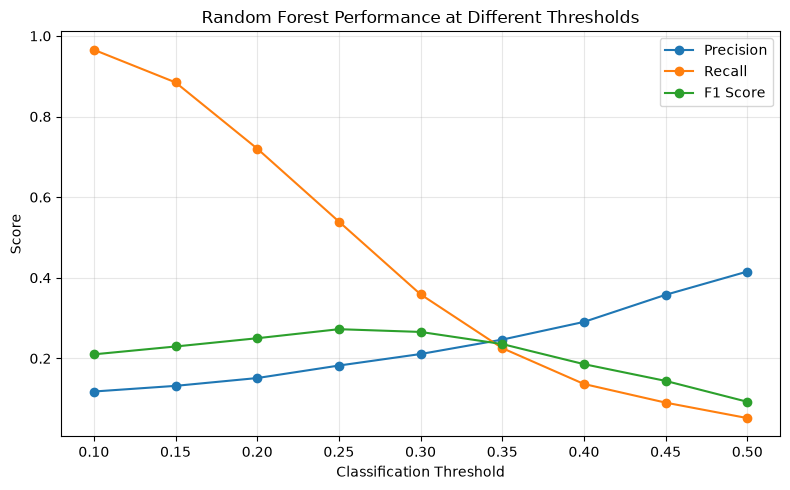

In [64]:
plt.figure(figsize=(8, 5))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["F1 Score"],
    marker="o",
    label="F1 Score"
)

plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.title("Random Forest Performance at Different Thresholds")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [65]:
best_threshold_row = threshold_df.loc[
    threshold_df["F1 Score"].idxmax()
]

best_threshold = best_threshold_row["Threshold"]

print("Best threshold based on F1 Score:", best_threshold)
print()

print(best_threshold_row)

Best threshold based on F1 Score: 0.25

Threshold    0.250000
Precision    0.182265
Recall       0.539410
F1 Score     0.272464
Name: 3, dtype: float64


In [66]:
y_pred_tuned = (y_prob >= best_threshold).astype(int)

print("Selected Threshold:", best_threshold)
print()

print("Classification Report")
print("---------------------")

print(
    classification_report(
        y_test,
        y_pred_tuned,
        target_names=[
            "Not Readmitted",
            "Readmitted <30 Days"
        ]
    )
)

Selected Threshold: 0.25

Classification Report
---------------------
                     precision    recall  f1-score   support

     Not Readmitted       0.92      0.70      0.79     18083
Readmitted <30 Days       0.18      0.54      0.27      2271

           accuracy                           0.68     20354
          macro avg       0.55      0.62      0.53     20354
       weighted avg       0.84      0.68      0.74     20354



Confusion Matrix:
[[12587  5496]
 [ 1046  1225]]


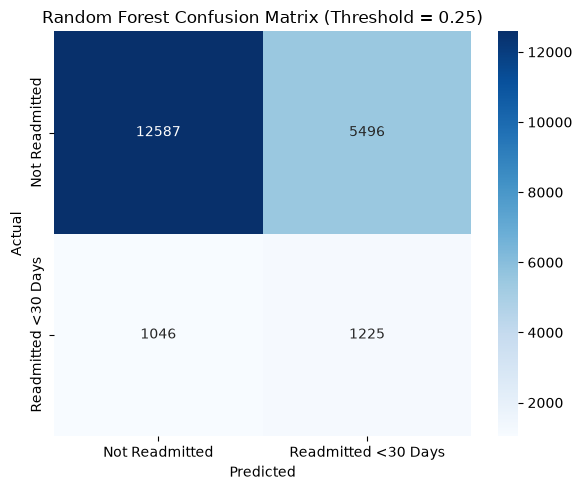

In [67]:
cm_tuned = confusion_matrix(
    y_test,
    y_pred_tuned
)

print("Confusion Matrix:")
print(cm_tuned)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_tuned,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "Not Readmitted",
        "Readmitted <30 Days"
    ],
    yticklabels=[
        "Not Readmitted",
        "Readmitted <30 Days"
    ]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(
    f"Random Forest Confusion Matrix "
    f"(Threshold = {best_threshold:.2f})"
)

plt.tight_layout()
plt.show()

In [68]:
default_precision = precision_score(y_test, y_pred)
default_recall = recall_score(y_test, y_pred)
default_f1 = f1_score(y_test, y_pred)

tuned_precision = precision_score(y_test, y_pred_tuned)
tuned_recall = recall_score(y_test, y_pred_tuned)
tuned_f1 = f1_score(y_test, y_pred_tuned)

comparison = pd.DataFrame({
    "Metric": [
        "Precision",
        "Recall",
        "F1 Score"
    ],
    "Default Threshold (0.50)": [
        default_precision,
        default_recall,
        default_f1
    ],
    "Tuned Threshold (0.25)": [
        tuned_precision,
        tuned_recall,
        tuned_f1
    ]
})

comparison

,Metric,Default Threshold (0.50),Tuned Threshold (0.25)
0,Precision,0.415441,0.182265
1,Recall,0.049758,0.539410
2,F1 Score,0.088871,0.272464


In [69]:
model_path = Path("../models/random_forest_model.pkl")

joblib.dump(
    rf_model,
    model_path
)

print(f"Random Forest model saved to: {model_path}")

Random Forest model saved to: ..\models\random_forest_model.pkl


In [70]:
import json

threshold_path = Path("../models/random_forest_threshold.json")

threshold_info = {
    "model": "Random Forest",
    "threshold": float(best_threshold),
    "selection_metric": "F1 Score"
}

with open(threshold_path, "w") as f:
    json.dump(threshold_info, f, indent=4)

print(f"Threshold saved to: {threshold_path}")

Threshold saved to: ..\models\random_forest_threshold.json


## Random Forest Summary

The Random Forest classifier was trained using the preprocessed hospital readmission dataset.

The model was evaluated using:
- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC
- Confusion Matrix
- ROC Curve
- Feature Importance

Because the dataset is imbalanced, the default classification threshold of 0.50 resulted in low recall for the 30-day readmission class.

Threshold analysis was therefore performed to identify a threshold that provides a better balance between precision and recall based on F1 Score.

The final selected threshold was determined from the validation results above.

## Conclusion

The Random Forest model achieved a ROC-AUC of approximately 0.66 at the default classification threshold.

Because the dataset is imbalanced, the default threshold of 0.50 resulted in very low recall for the 30-day readmission class.

Threshold analysis was performed using thresholds from 0.10 to 0.50. Among the evaluated thresholds, 0.25 achieved the highest F1-score of 0.2725.

At the selected threshold of 0.25, recall for the 30-day readmission class increased from 0.0498 to 0.5394, while precision decreased from 0.4154 to 0.1823.

Therefore, a threshold of 0.25 was selected as the operating threshold for the Random Forest model because it provides a better balance between precision and recall based on F1-score.